<a href="https://colab.research.google.com/github/suryanshshah2006/Sleep-stage-classification-using-EEG-data-/blob/main/Sleep_Stage_classification_using_EEG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install mne pyedflib openneuro-py

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 10.0 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!wget -q -O participants.tsv \
https://github.com/OpenNeuroDatasets/ds007181/raw/main/participants.tsv

In [4]:
!rm -rf /content/ds007181_meta
!git clone --depth 1 --filter=blob:none --sparse https://github.com/OpenNeuroDatasets/ds007181.git /content/ds007181_meta

Cloning into '/content/ds007181_meta'...
remote: Enumerating objects: 239, done.
remote: Counting objects: 100% (239/239), done.
remote: Compressing objects: 100% (173/173), done.
remote: Total 239 (delta 56), reused 237 (delta 55), pack-reused 0 (from 0)
Receiving objects: 100% (239/239), 21.64 KiB | 3.61 MiB/s, done.
Resolving deltas: 100% (56/56), done.
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 7 (delta 0), reused 7 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (7/7), 3.08 KiB | 1.54 MiB/s, done.


In [5]:
%cd /content/ds007181_meta

!git sparse-checkout init --no-cone

!git sparse-checkout set \
  participants.tsv \
  "sub-*/eeg/*_channels.tsv" \
  "sub-*/eeg/*_events.tsv"

!git checkout

/content/ds007181_meta
remote: Enumerating objects: 60, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 60 (delta 8), reused 60 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (60/60), 123.36 KiB | 5.87 MiB/s, done.
Resolving deltas: 100% (8/8), done.
Your branch is up to date with 'origin/main'.


In [6]:
!pip install mne matplotlib pandas

from google.colab import drive
import os
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
import pandas as pd
import os
import glob

chunks_folder = '/content/drive/MyDrive/EEG_Full_58_Subjects'
meta_base_path = '/content/ds007181_meta'

label_mapping = {
    'W': 0, 'Sleep stage W': 0,
    'N1': 1, 'Sleep stage N1': 1,
    'N2': 2, 'Sleep stage N2': 2,
    'N3': 3, 'Sleep stage N3': 3,
    'R': 4, 'REM': 4, 'Sleep stage R': 4
}

all_labels = []

processed_files = glob.glob(os.path.join(chunks_folder, '*_seg_0.npy'))
subjects = [os.path.basename(f).split('_')[0] for f in processed_files]
print(f"Generating labels for {len(subjects)} subjects...")

for sub in subjects:
    tsv_path = os.path.join(meta_base_path, sub, 'eeg', f'{sub}_task-sleep_acq-PSG_events.tsv')

    if not os.path.exists(tsv_path):
        tsv_path = os.path.join(meta_base_path, f'{sub}_task-sleep_acq-PSG_events.tsv')
        if not os.path.exists(tsv_path):
            continue

    events_df = pd.read_csv(tsv_path, sep='\t')

    if 'stage' in events_df.columns: label_col = 'stage'
    elif 'value' in events_df.columns: label_col = 'value'
    elif 'trial_type' in events_df.columns: label_col = 'trial_type'
    else: continue

    epoch_duration = 30

    for index, row in events_df.iterrows():
        onset = row['onset']
        duration = row['duration']
        label = row[label_col]

        start_chunk_idx = int(onset // epoch_duration)
        num_chunks = int(duration // epoch_duration)

        for i in range(num_chunks):
            chunk_idx = start_chunk_idx + i
            filename = f"{sub}_seg_{chunk_idx}.npy"
            filepath = os.path.join(chunks_folder, filename)

            all_labels.append({
                'filename': filename,
                'label': label,
                'filepath': filepath,
                'subject': sub
            })

master_df = pd.DataFrame(all_labels)
master_df['label_code'] = master_df['label'].map(label_mapping)
master_df = master_df.dropna(subset=['label_code'])

print(f"Total labeled samples: {len(master_df)}")
master_df.to_csv('/content/drive/MyDrive/EEG_Full_58_Subjects/master_labels_full.csv', index=False)

Generating labels for 52 subjects...
Total labeled samples: 48355


In [9]:
import pandas as pd
import os
import glob

PROCESSED_PATH = '/content/drive/MyDrive/EEG_Full_58_Subjects'
META_PATH = '/content/ds007181_meta'
OUTPUT_CSV = os.path.join(PROCESSED_PATH, 'master_labels_clean.csv')

label_mapping = {
    'W': 0, 'Sleep stage W': 0,
    'N1': 1, 'Sleep stage N1': 1,
    'N2': 2, 'Sleep stage N2': 2,
    'N3': 3, 'Sleep stage N3': 3,
    'R': 4, 'REM': 4, 'Sleep stage R': 4
}

print("1. Scanning for processed files on Drive...")
processed_files = glob.glob(os.path.join(PROCESSED_PATH, '*_seg_0.npy'))
subjects = sorted(list(set([os.path.basename(f).split('_')[0] for f in processed_files])))
print(f"✅ Found {len(subjects)} subjects with data.")

all_labels = []

print("2. Matching files to labels (This takes ~60 seconds)...")
for sub in subjects:
    tsv_path = os.path.join(META_PATH, sub, 'eeg', f'{sub}_task-sleep_acq-PSG_events.tsv')
    if not os.path.exists(tsv_path):
        tsv_path = os.path.join(META_PATH, f'{sub}_task-sleep_acq-PSG_events.tsv')
        if not os.path.exists(tsv_path): continue

    try:
        events_df = pd.read_csv(tsv_path, sep='\t')
    except: continue

    col = next((c for c in ['stage', 'value', 'trial_type'] if c in events_df.columns), None)
    if not col: continue

    for _, row in events_df.iterrows():
        onset = row['onset']
        duration = row['duration']
        label = row[col]

        start_chunk = int(onset // 30)
        num_chunks = int(duration // 30)

        for i in range(num_chunks):
            fname = f"{sub}_seg_{start_chunk + i}.npy"
            fpath = os.path.join(PROCESSED_PATH, fname)

            all_labels.append({
                'filename': fname,
                'label': label,
                'filepath': fpath,
                'subject': sub
            })

master_df = pd.DataFrame(all_labels)
master_df['label_code'] = master_df['label'].map(label_mapping)
master_df = master_df.dropna(subset=['label_code'])

print(f"3. Verifying file existence for {len(master_df)} samples...")
master_df['exists'] = master_df['filepath'].apply(os.path.exists)
clean_df = master_df[master_df['exists'] == True].copy()

clean_df.to_csv(OUTPUT_CSV, index=False)
print(f"\n🎉 SUCCESS! Saved clean list to: {OUTPUT_CSV}")
print(f"Total valid samples: {len(clean_df)}")

1. Scanning for processed files on Drive...
✅ Found 52 subjects with data.
2. Matching files to labels (This takes ~60 seconds)...
3. Verifying file existence for 48355 samples...

🎉 SUCCESS! Saved clean list to: /content/drive/MyDrive/EEG_Full_58_Subjects/master_labels_clean.csv
Total valid samples: 47090


In [10]:
import os
import shutil
import numpy as np
from concurrent.futures import ThreadPoolExecutor
from tqdm.notebook import tqdm

SOURCE_DIR = '/content/drive/MyDrive/EEG_Full_58_Subjects'
DEST_DIR = '/content/local_eeg_data'
DOWNSAMPLE = 10

TARGET_SUBS = [f'sub-{i:02d}' for i in range(1, 60)]

print("🧹 Wiping old local data to make room...")
if os.path.exists(DEST_DIR):
    shutil.rmtree(DEST_DIR)
os.makedirs(DEST_DIR, exist_ok=True)

print("🔍 Scanning Drive for ALL subjects...")
all_files = os.listdir(SOURCE_DIR)

files_to_copy = [f for f in all_files if any(f.startswith(sub) for sub in TARGET_SUBS)]
print(f"✅ Found {len(files_to_copy)} total files. (Expected: ~47,000)")

def smart_copy(filename):
    try:
        src = os.path.join(SOURCE_DIR, filename)
        data = np.load(src)
        data = data[:, ::DOWNSAMPLE].astype(np.float16)
        dst = os.path.join(DEST_DIR, filename)
        np.save(dst, data)
    except Exception:
        pass

print(f"🚀 Copying & Compressing {len(files_to_copy)} files... (Go grab a coffee, this takes ~45 mins)")
with ThreadPoolExecutor(max_workers=8) as executor:
    list(tqdm(executor.map(smart_copy, files_to_copy), total=len(files_to_copy)))

print("\n🎉 MASSIVE Transfer Complete! You now have the full dataset locally.")

🧹 Wiping old local data to make room...
🔍 Scanning Drive for ALL subjects...
✅ Found 40614 total files. (Expected: ~47,000)
🚀 Copying & Compressing 40614 files... (Go grab a coffee, this takes ~45 mins)


  0%|          | 0/40614 [00:00<?, ?it/s]


🎉 MASSIVE Transfer Complete! You now have the full dataset locally.


In [ ]:
import pandas as pd
import numpy as np
import os
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

print("1. Syncing Master List with Local Files...")
LOCAL_DIR = '/content/local_eeg_data'
CSV_PATH = '/content/drive/MyDrive/EEG_Full_58_Subjects/master_labels_clean.csv'

master_df = pd.read_csv(CSV_PATH)

local_files = set(os.listdir(LOCAL_DIR))
print(f"Found {len(local_files)} files in local directory.")

local_df = master_df[master_df['filename'].isin(local_files)].copy()

local_df['filepath'] = local_df['filename'].apply(lambda x: os.path.join(LOCAL_DIR, x))

print(f"✅ Filtered down to {len(local_df)} matched samples ready for massive training.")

train_df, val_df = train_test_split(
    local_df, test_size=0.2, random_state=42, stratify=local_df['label_code']
)
print(f"✅ Split complete: {len(train_df)} Train | {len(val_df)} Val")

class EEGDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, df, batch_size=64, n_classes=5):
        self.df = df
        self.batch_size = batch_size
        self.n_classes = n_classes
        self.indices = np.arange(len(self.df))

    def __len__(self):
        return int(np.floor(len(self.df) / self.batch_size))

    def __getitem__(self, index):
        batch_indices = self.indices[index*self.batch_size : (index+1)*self.batch_size]
        batch_df = self.df.iloc[batch_indices]
        X, y = [], []
        for _, row in batch_df.iterrows():
            data = np.load(row['filepath']).astype(np.float32)

            mean, std = np.mean(data), np.std(data)
            data = (data - mean) / std if std > 0 else data - mean

            X.append(data)
            y.append(row['label_code'])
        return np.array(X), to_categorical(np.array(y), num_classes=self.n_classes)

    def on_epoch_end(self):
        np.random.shuffle(self.indices)

train_gen = EEGDataGenerator(train_df, batch_size=64)
val_gen = EEGDataGenerator(val_df, batch_size=64)

print("\n2. Configuring Model Shape...")
sample_shape = np.load(train_df.iloc[0]['filepath']).shape
n_channels = sample_shape[0]
n_points = sample_shape[1]
print(f"✅ Input Shape: Channels={n_channels}, Timepoints={n_points}")
print("\n3. Building Model...")
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(n_channels, n_points)),
    tf.keras.layers.Permute((2, 1)),

    tf.keras.layers.Conv1D(32, 64, padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling1D(4),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv1D(64, 32, padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling1D(4),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=False)),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(5, activation='softmax')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

y_train = train_df['label_code'].values
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)

print("\n🚀 Starting Fast Training on Full Dataset for 50 Epochs...")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    class_weight=dict(enumerate(weights)),
    callbacks=[
        ModelCheckpoint('/content/drive/MyDrive/sleep_model_bilstm_FULL.keras', save_best_only=True, monitor='val_accuracy'),
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    ]
)

1. Syncing Master List with Local Files...
Found 40614 files in local directory.
✅ Filtered down to 40612 matched samples ready for massive training.
✅ Split complete: 32489 Train | 8123 Val

2. Configuring Model Shape...
✅ Input Shape: Channels=24, Timepoints=3072

3. Building Model...

🚀 Starting Fast Training on Full Dataset for 50 Epochs...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 124s 233ms/step - accuracy: 0.2781 - loss: 1.4887 - val_accuracy: 0.4871 - val_loss: 1.2323
Epoch 2/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 92s 182ms/step - accuracy: 0.5047 - loss: 1.0987 - val_accuracy: 0.5794 - val_loss: 0.9764
Epoch 3/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 82s 162ms/step - accuracy: 0.6134 - loss: 0.9259 - val_accuracy: 0.6261 - val_loss: 1.0365
Epoch 4/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 81s 160ms/step - accuracy: 0.5981 - loss: 0.9376 - val_accuracy: 0.6064 - val_loss: 0.9669
Epoch 5/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 82s 161ms/step - accuracy: 0.6521 - loss: 0.8302 - val_accuracy: 0.6683 - val_loss: 0.8417
Epoch 6/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 81s 160ms/step - accuracy: 0.6652 - loss: 0.8077 - val_accuracy: 0.6713 - val_loss: 0.8313
Epoch 7/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 84s 166ms/step - accuracy: 0.6895 - loss: 0.7382 - val_accuracy: 0.7186 - val_loss: 0.7361
Epoch 8/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 82s 162ms/step - accuracy: 0.7030 - loss: 

In [ ]:
import pandas as pd
import numpy as np
import os
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

print("1. Syncing Master List with Local Files...")
LOCAL_DIR = '/content/local_eeg_data'
CSV_PATH = '/content/drive/MyDrive/EEG_Full_58_Subjects/master_labels_clean.csv'

master_df = pd.read_csv(CSV_PATH)

local_files = set(os.listdir(LOCAL_DIR))
print(f"Found {len(local_files)} files in local directory.")

local_df = master_df[master_df['filename'].isin(local_files)].copy()

local_df['filepath'] = local_df['filename'].apply(lambda x: os.path.join(LOCAL_DIR, x))

print(f"✅ Filtered down to {len(local_df)} matched samples ready for massive training.")

train_df, val_df = train_test_split(
    local_df, test_size=0.2, random_state=42, stratify=local_df['label_code']
)
print(f"✅ Split complete: {len(train_df)} Train | {len(val_df)} Val")

class EEGDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, df, batch_size=64, n_classes=5):
        self.df = df
        self.batch_size = batch_size
        self.n_classes = n_classes
        self.indices = np.arange(len(self.df))

    def __len__(self):
        return int(np.floor(len(self.df) / self.batch_size))

    def __getitem__(self, index):
        batch_indices = self.indices[index*self.batch_size : (index+1)*self.batch_size]
        batch_df = self.df.iloc[batch_indices]
        X, y = [], []
        for _, row in batch_df.iterrows():
            data = np.load(row['filepath']).astype(np.float32)
            mean, std = np.mean(data), np.std(data)
            data = (data - mean) / std if std > 0 else data - mean
            X.append(data)
            y.append(row['label_code'])
        return np.array(X), to_categorical(np.array(y), num_classes=self.n_classes)

    def on_epoch_end(self):
        np.random.shuffle(self.indices)

train_gen = EEGDataGenerator(train_df, batch_size=64)
val_gen = EEGDataGenerator(val_df, batch_size=64)

print("\n2. Configuring Model Shape...")
sample_shape = np.load(train_df.iloc[0]['filepath']).shape
n_channels = sample_shape[0]
n_points = sample_shape[1]
print(f"✅ Input Shape: Channels={n_channels}, Timepoints={n_points}")
-
print("\n3. Building SOTA Multi-Scale Model...")
inputs = tf.keras.layers.Input(shape=(n_channels, n_points))
x = tf.keras.layers.Permute((2, 1))(inputs) # (Time, Channels)

conv_fine = tf.keras.layers.Conv1D(64, kernel_size=32, strides=4, padding='same', activation='relu')(x)
conv_fine = tf.keras.layers.BatchNormalization()(conv_fine)
conv_fine = tf.keras.layers.MaxPooling1D(4)(conv_fine)

conv_coarse = tf.keras.layers.Conv1D(64, kernel_size=200, strides=4, padding='same', activation='relu')(x)
conv_coarse = tf.keras.layers.BatchNormalization()(conv_coarse)
conv_coarse = tf.keras.layers.MaxPooling1D(4)(conv_coarse)

merged_cnn = tf.keras.layers.Concatenate(axis=-1)([conv_fine, conv_coarse])
merged_cnn = tf.keras.layers.Dropout(0.4)(merged_cnn)

lstm_out = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True))(merged_cnn)
lstm_out = tf.keras.layers.Dropout(0.4)(lstm_out)

attention_out = tf.keras.layers.Attention()([lstm_out, lstm_out])
pooled = tf.keras.layers.GlobalAveragePooling1D()(attention_out)

dense = tf.keras.layers.Dense(64, activation='relu')(pooled)
dense = tf.keras.layers.Dropout(0.5)(dense)
outputs = tf.keras.layers.Dense(5, activation='softmax')(dense)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

print("\n🚀 Starting SOTA Training for 50 Epochs...")

focal_loss = tf.keras.losses.CategoricalFocalCrossentropy(alpha=0.25, gamma=2.0)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

model.compile(optimizer=optimizer, loss=focal_loss, metrics=['accuracy'])

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=[
        ModelCheckpoint('/content/drive/MyDrive/sleep_model_SOTA.keras', save_best_only=True, monitor='val_accuracy'),
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    ]
)

1. Syncing Master List with Local Files...
Found 40614 files in local directory.
✅ Filtered down to 40612 matched samples ready for massive training.
✅ Split complete: 32489 Train | 8123 Val

2. Configuring Model Shape...
✅ Input Shape: Channels=24, Timepoints=3072

3. Building SOTA Multi-Scale Model...

🚀 Starting SOTA Training for 50 Epochs...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 89s 160ms/step - accuracy: 0.5942 - loss: 0.1425 - val_accuracy: 0.7573 - val_loss: 0.0714
Epoch 2/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 81s 159ms/step - accuracy: 0.7508 - loss: 0.0718 - val_accuracy: 0.7842 - val_loss: 0.0605
Epoch 3/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 82s 161ms/step - accuracy: 0.7773 - loss: 0.0605 - val_accuracy: 0.7809 - val_loss: 0.0575
Epoch 4/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 81s 160ms/step - accuracy: 0.7916 - loss: 0.0545 - val_accuracy: 0.7724 - val_loss: 0.0562
Epoch 5/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 81s 159ms/step - accuracy: 0.7952 - loss: 0.0507 - val_accuracy: 0.7923 - val_loss: 0.0549
Epoch 6/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 80s 158ms/step - accuracy: 0.8018 - loss: 0.0481 - val_accuracy: 0.7755 - val_loss: 0.0564
Epoch 7/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 81s 160ms/step - accuracy: 0.8107 - loss: 0.0468 - val_accuracy: 0.7907 - val_loss: 0.0519
Epoch 8/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 81s 159ms/step - accuracy: 0.8148 - loss: 0

In [14]:
print("\n2. Configuring Model Shape...")
sample_data = np.load(train_df.iloc[0]['filepath'])
n_channels = sample_data.shape[0]
n_points = sample_data.shape[1]
print(f"✅ Input Shape Detected: Channels={n_channels}, Timepoints={n_points}")

print("\n3. Building Memory-Safe Tuned Model...")
inputs = tf.keras.layers.Input(shape=(n_channels, n_points))


2. Configuring Model Shape...
✅ Input Shape Detected: Channels=24, Timepoints=3072

3. Building Memory-Safe Tuned Model...


In [15]:
import pandas as pd
import numpy as np
import os
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

print("1. Syncing Master List with Local Files...")
LOCAL_DIR = '/content/local_eeg_data'
CSV_PATH = '/content/drive/MyDrive/EEG_Full_58_Subjects/master_labels_clean.csv'

master_df = pd.read_csv(CSV_PATH)

local_files = set(os.listdir(LOCAL_DIR))
print(f"Found {len(local_files)} files in local directory.")

local_df = master_df[master_df['filename'].isin(local_files)].copy()

local_df['filepath'] = local_df['filename'].apply(lambda x: os.path.join(LOCAL_DIR, x))

print(f"✅ Filtered down to {len(local_df)} matched samples ready for massive training.")

train_df, val_df = train_test_split(
    local_df, test_size=0.2, random_state=42, stratify=local_df['label_code']
)
print(f"✅ Split complete: {len(train_df)} Train | {len(val_df)} Val")

class EEGDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, df, batch_size=64, n_classes=5):
        self.df = df
        self.batch_size = batch_size
        self.n_classes = n_classes
        self.indices = np.arange(len(self.df))

    def __len__(self):
        return int(np.floor(len(self.df) / self.batch_size))

    def __getitem__(self, index):
        batch_indices = self.indices[index*self.batch_size : (index+1)*self.batch_size]
        batch_df = self.df.iloc[batch_indices]
        X, y = [], []
        for _, row in batch_df.iterrows():
            data = np.load(row['filepath']).astype(np.float32)
            mean, std = np.mean(data), np.std(data)
            data = (data - mean) / std if std > 0 else data - mean
            X.append(data)
            y.append(row['label_code'])
        return np.array(X), to_categorical(np.array(y), num_classes=self.n_classes)

    def on_epoch_end(self):
        np.random.shuffle(self.indices)

train_gen = EEGDataGenerator(train_df, batch_size=32)
val_gen = EEGDataGenerator(val_df, batch_size=32)

print("\n3. Building Memory-Safe Tuned Model...")
inputs = tf.keras.layers.Input(shape=(n_channels, n_points))
x = tf.keras.layers.Permute((2, 1))(inputs)

s1 = tf.keras.layers.Conv1D(32, 32, strides=4, padding='same', activation='relu')(x)
s2 = tf.keras.layers.Conv1D(32, 128, strides=4, padding='same', activation='relu')(x)
merged = tf.keras.layers.Concatenate(axis=-1)([s1, s2])
merged = tf.keras.layers.BatchNormalization()(merged)
merged = tf.keras.layers.MaxPooling1D(4)(merged)
merged = tf.keras.layers.Dropout(0.3)(merged)

lstm_out = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True))(merged)
attention_out = tf.keras.layers.Attention()([lstm_out, lstm_out])
pooled = tf.keras.layers.GlobalAveragePooling1D()(attention_out)

dense = tf.keras.layers.Dense(64, activation='relu')(pooled)
outputs = tf.keras.layers.Dense(5, activation='softmax')(dense)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

lr_reducer = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

print("\n🚀 Starting Safe Training...")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint('/content/drive/MyDrive/sleep_model_SAFE_TUNED.keras',
                                           save_best_only=True, monitor='val_accuracy'),
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        lr_reducer
    ]
)

1. Syncing Master List with Local Files...
Found 40614 files in local directory.
✅ Filtered down to 40612 matched samples ready for massive training.
✅ Split complete: 32489 Train | 8123 Val

3. Building Memory-Safe Tuned Model...

🚀 Starting Safe Training...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 156s 145ms/step - accuracy: 0.6543 - loss: 1.0567 - val_accuracy: 0.7801 - val_loss: 0.8114 - learning_rate: 5.0000e-04
Epoch 2/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 138s 136ms/step - accuracy: 0.7826 - loss: 0.8077 - val_accuracy: 0.7938 - val_loss: 0.7856 - learning_rate: 5.0000e-04
Epoch 3/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 115s 114ms/step - accuracy: 0.8019 - loss: 0.7667 - val_accuracy: 0.7879 - val_loss: 0.7906 - learning_rate: 5.0000e-04
Epoch 4/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 137s 109ms/step - accuracy: 0.8136 - loss: 0.7472 - val_accuracy: 0.8093 - val_loss: 0.7556 - learning_rate: 5.0000e-04
Epoch 5/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 91s 90ms/step - accuracy: 0.8173 - loss: 0.7361 - val_accuracy: 0.8100 - val_loss: 0.7566 - learning_rate: 5.0000e-04
Epoch 6/50
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 88s 86ms/step - accuracy: 0.8224 - loss: 0.7254 - val_accuracy: 0.8194 - val_loss: 0.7404 - learning_rate: 5.0000e-04
Epoch 7/50
1015/1015 ━━━━━━━━━━━

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Evaluate to get the 'Best' weights results (restored by EarlyStopping)
print("\n📊 Evaluating Best Model (Restored Weights)...")
val_loss, val_acc = model.evaluate(val_gen)
# Note: To get true training acc of the best weights, we evaluate on train_gen
train_loss, train_acc = model.evaluate(train_gen)

print(f"\n✅ Final Train Accuracy: {train_acc*100:.2f}%")
print(f"✅ Final Validation Accuracy: {val_acc*100:.2f}%")


📊 Evaluating Best Model (Restored Weights)...
253/253 ━━━━━━━━━━━━━━━━━━━━ 19s 75ms/step - accuracy: 0.8366 - loss: 0.7220
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 68s 67ms/step - accuracy: 0.9121 - loss: 0.5700

✅ Final Train Accuracy: 91.01%
✅ Final Validation Accuracy: 83.42%



🔍 Running Locked Evaluation (No Shuffle)...

✅ REAL Final Validation Accuracy: 83.38685770750988 %

📋 REAL Classification Report:
              precision    recall  f1-score   support

           W       0.81      0.84      0.83      1095
          N1       0.68      0.53      0.60      1024
          N2       0.86      0.89      0.87      3835
          N3       0.82      0.83      0.82       978
         REM       0.89      0.91      0.90      1164

    accuracy                           0.83      8096
   macro avg       0.81      0.80      0.80      8096
weighted avg       0.83      0.83      0.83      8096



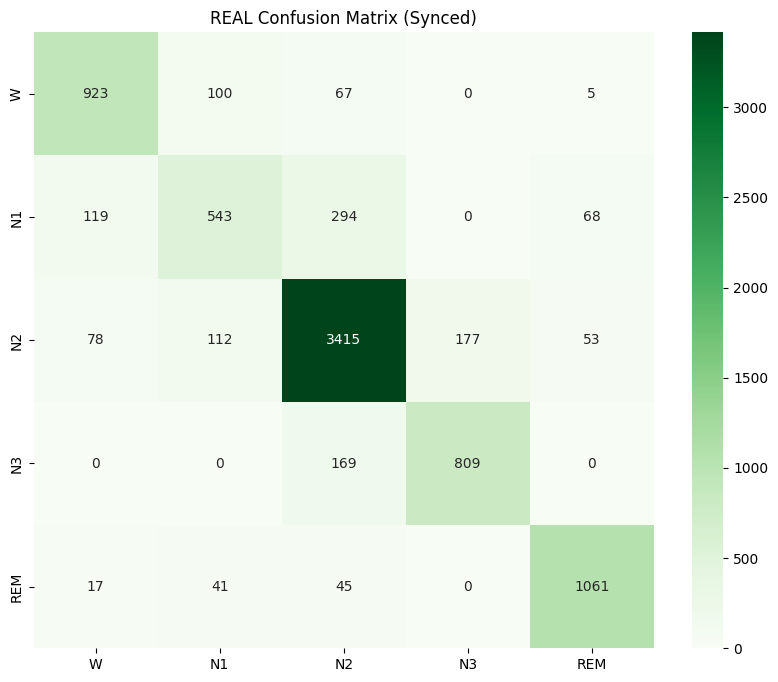

In [17]:
print("\n🔍 Running Locked Evaluation (No Shuffle)...")

class EvalGenerator(EEGDataGenerator):
    def __init__(self, df, batch_size=32, n_classes=5):
        super().__init__(df, batch_size, n_classes)
        self.indices = np.arange(len(self.df))
    def on_epoch_end(self):
        pass

eval_gen = EvalGenerator(val_df, batch_size=32)

y_true = []
y_pred_probs = []

for i in range(len(eval_gen)):
    X_batch, y_batch = eval_gen[i]
    y_true.extend(np.argmax(y_batch, axis=1))

    batch_preds = model.predict_on_batch(X_batch)
    y_pred_probs.extend(batch_preds)

y_true = np.array(y_true)
y_pred = np.argmax(np.array(y_pred_probs), axis=1)

class_labels = ['W', 'N1', 'N2', 'N3', 'REM']
print("\n✅ REAL Final Validation Accuracy:", np.mean(y_true == y_pred) * 100, "%")

print("\n📋 REAL Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('REAL Confusion Matrix (Synced)')
plt.show()